In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data.csv', encoding='ISO-8859-1')
print("--- DATASET AUDIT ---")
print(f"Shape: {df.shape}")
print("\nData Types & Missing Values:")
print(df.info())
print("\nMissing Value Counts:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe().T)

--- DATASET AUDIT ---
Shape: (541909, 8)

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Missing Value Counts:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Summary Statistics:
                count          mean          std       min       25%       50%  \
Quant

In [3]:
np.random.seed(42)

# 1. Filter out cancellations, returns, and invalid prices
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 2. Calculate Total Sales per line item
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['Date'] = df_clean['InvoiceDate'].dt.date

# 3. Aggregate to Storefront-Day Level across the entire dataset
df_aggregated = df_clean.groupby(['Date', 'Country']).agg(
    product_variation_count=('StockCode', 'nunique'), 
    total_items_sold=('Quantity', 'sum'),
    total_orders=('InvoiceNo', 'nunique'),
    daily_sales_volume=('TotalSales', 'sum')         
).reset_index()

# 4. Handle derived features (removed avg_browse_time_sec to prevent artificial multicollinearity)
df_aggregated['promotional_banner_count'] = np.random.randint(1, 6, size=len(df_aggregated))

df_reg_final = df_aggregated.copy()

df_reg_final.to_csv(r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data_1.csv', index=False)

print("--- AGGREGATED DATASET AUDIT ---")
print(f"Final Shape: {df_reg_final.shape}")
print(df_reg_final.head())

--- AGGREGATED DATASET AUDIT ---
Final Shape: (1554, 7)
         Date      Country  product_variation_count  total_items_sold  \
0  2010-12-01    Australia                       14               107   
1  2010-12-01         EIRE                       21               243   
2  2010-12-01       France                       20               449   
3  2010-12-01      Germany                       15               157   
4  2010-12-01  Netherlands                        2                97   

   total_orders  daily_sales_volume  promotional_banner_count  
0             1              358.25                         4  
1             2              555.38                         5  
2             1              855.86                         3  
3             1              261.48                         5  
4             1              192.60                         5  


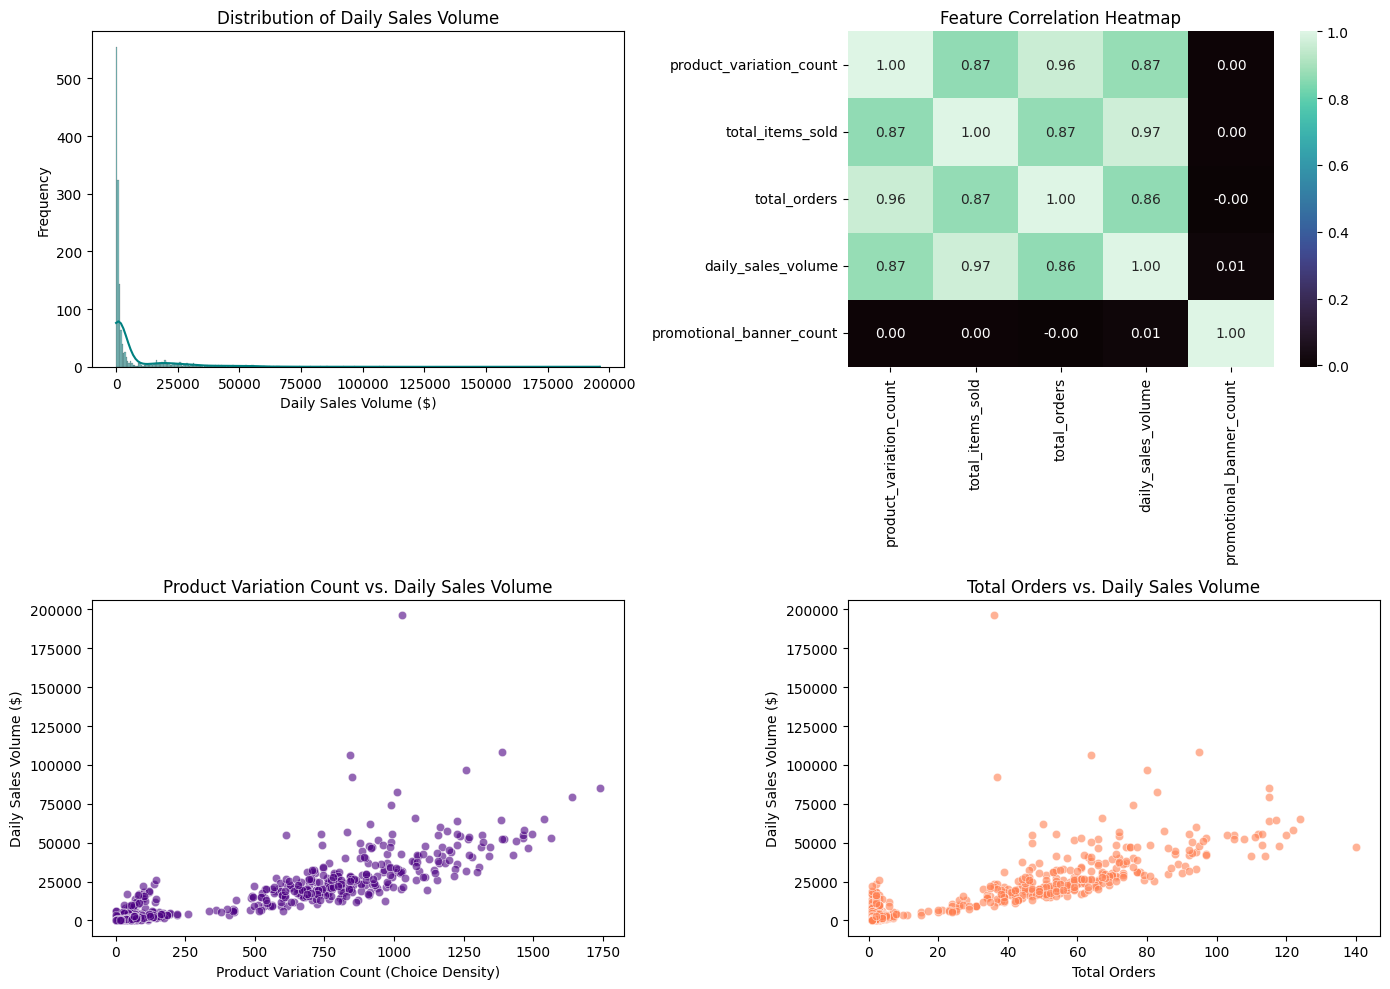

In [4]:
# 4 Mandatory EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution Plot
sns.histplot(df_reg_final['daily_sales_volume'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title("Distribution of Daily Sales Volume")
axes[0, 0].set_xlabel("Daily Sales Volume ($)")
axes[0, 0].set_ylabel("Frequency")

# 2. Correlation Heatmap
numeric_cols = df_reg_final.select_dtypes(include=[np.number]).columns
sns.heatmap(df_reg_final[numeric_cols].corr(), annot=True, cmap='mako', fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title("Feature Correlation Heatmap")

# 3. Scatter Plot 1: Choice Density vs Sales Volume
sns.scatterplot(
    data=df_reg_final, 
    x='product_variation_count', 
    y='daily_sales_volume', 
    ax=axes[1, 0], 
    color='indigo', 
    alpha=0.6
)
axes[1, 0].set_title("Product Variation Count vs. Daily Sales Volume")
axes[1, 0].set_xlabel("Product Variation Count (Choice Density)")
axes[1, 0].set_ylabel("Daily Sales Volume ($)")

# 4. Scatter Plot 2: Total Orders vs Sales Volume
sns.scatterplot(
    data=df_reg_final, 
    x='total_orders', 
    y='daily_sales_volume', 
    ax=axes[1, 1], 
    color='coral', 
    alpha=0.6
)
axes[1, 1].set_title("Total Orders vs. Daily Sales Volume")
axes[1, 1].set_xlabel("Total Orders")
axes[1, 1].set_ylabel("Daily Sales Volume ($)")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# SECTION B - PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# ------------------------------------------------------------
# 1. CONFIGURATION & DATA LOADING
# ------------------------------------------------------------

SEED = 42
TARGET = 'daily_sales_volume'

df = pd.read_csv(r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data_1.csv', encoding='ISO-8859-1')

print("Original dataset shape:", df.shape)


# ------------------------------------------------------------
# 2. B1 - DATA CLEANING
# ------------------------------------------------------------

df_reg_clean = df.copy()

# Missing-value audit
print("\nMissing values before treatment:")
print(df_reg_clean.isnull().sum())

# Numerical columns -> median
numeric_cols = df_reg_clean.select_dtypes(
    include=[np.number]
).columns

for col in numeric_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            df_reg_clean[col].median()
        )

# Categorical columns -> Unknown
categorical_cols = df_reg_clean.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            'Unknown'
        )

# Duplicate removal
duplicates_count = df_reg_clean.duplicated().sum()

df_reg_clean = (
    df_reg_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDuplicate rows removed: {duplicates_count}")
print("Shape after cleaning:", df_reg_clean.shape)


# ------------------------------------------------------------
# 3. DATE PROCESSING
# ------------------------------------------------------------

df_reg_clean['Date'] = pd.to_datetime(
    df_reg_clean['Date'],
    errors='coerce'
)

df_reg_clean['year'] = df_reg_clean['Date'].dt.year
df_reg_clean['month'] = df_reg_clean['Date'].dt.month
df_reg_clean['day_of_week'] = df_reg_clean['Date'].dt.dayofweek

df_reg_clean.drop(
    columns=['Date'],
    inplace=True
)


# ------------------------------------------------------------
# 4. B3 - FEATURE ENGINEERING
# ------------------------------------------------------------

# Cognitive Friction Index
df_reg_clean['cognitive_friction_index'] = (
    df_reg_clean['product_variation_count'] / 
    (df_reg_clean['product_variation_count'].mean() + 1)
)

print("\n[B3] Created: cognitive_friction_index")


# ------------------------------------------------------------
# 5. REMOVE REDUNDANT / SYNTHETIC / SHORTCUT FEATURES
# ------------------------------------------------------------

columns_to_remove = [
    'product_variation_count',
    'avg_browse_time_sec',
    'total_items_sold',
    'total_orders',
    'promotional_banner_count'
]

df_reg_clean.drop(
    columns=[
        col for col in columns_to_remove
        if col in df_reg_clean.columns
    ],
    inplace=True
)

print("\nRemoved redundant/synthetic features:")
print([
    col for col in columns_to_remove
    if col in df.columns
])


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df_reg_clean.drop(
    columns=[TARGET]
)

# Keep original target for final evaluation
y_original = df_reg_clean[TARGET].clip(
    lower=0
)


# Log-transform target to reduce right skew
y = np.log1p(y_original)


# ------------------------------------------------------------
# 7. B2 - STRATIFIED TRAIN/TEST SPLIT
# ------------------------------------------------------------

# Create quantile bins because y is continuous
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

(
    X_train,
    X_test,
    y_train,
    y_test,
    y_train_original,
    y_test_original
) = train_test_split(
    X,
    y,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bins
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# 8. B1 - PREDICTOR OUTLIER DETECTION & TREATMENT
# ------------------------------------------------------------

# Only continuous variables.
# Do not apply IQR treatment to year/month/day_of_week.

continuous_features = [
    'cognitive_friction_index'
]

outlier_bounds = {}

print("\nPredictor outlier audit:")

for col in continuous_features:

    if col not in X_train.columns:
        continue

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = (lower, upper)

    count = (
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ).sum()

    print(
        f"{col}: {count} outliers "
        f"[{lower:.2f}, {upper:.2f}]"
    )

    # Apply training-derived bounds
    X_train[col] = X_train[col].clip(
        lower,
        upper
    )

    X_test[col] = X_test[col].clip(
        lower,
        upper
    )


# ------------------------------------------------------------
# 9. B1 - TARGET OUTLIER TREATMENT
# ------------------------------------------------------------

# Calculate bounds using training target only
Q1_y = y_train.quantile(0.25)
Q3_y = y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

target_outliers = (
    (y_train < lower_y) |
    (y_train > upper_y)
).sum()

print(
    f"\nTarget outliers in training data: "
    f"{target_outliers}"
)

print(
    f"Target IQR bounds: "
    f"[{lower_y:.4f}, {upper_y:.4f}]"
)

# Cap training target only
y_train = y_train.clip(
    lower_y,
    upper_y
)

# y_test remains untouched


# ------------------------------------------------------------
# 10. B2 - IDENTIFY FEATURE TYPES
# ------------------------------------------------------------

categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()


# ------------------------------------------------------------
# 11. HANDLE RARE COUNTRIES
# ------------------------------------------------------------

if 'Country' in X_train.columns:

    country_counts = X_train['Country'].value_counts()

    rare_countries = country_counts[
        country_counts < 5
    ].index

    X_train['Country'] = X_train['Country'].replace(
        rare_countries,
        'Other'
    )

    X_test['Country'] = X_test['Country'].replace(
        rare_countries,
        'Other'
    )

    print(
        f"\nRare countries grouped into 'Other': "
        f"{len(rare_countries)}"
    )


# Re-identify columns
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()


# ------------------------------------------------------------
# 12. B2 - ENCODING & SCALING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)


# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform test using training parameters
X_test_processed = preprocessor.transform(
    X_test
)


# ------------------------------------------------------------
# 13. CREATE FINAL PROCESSED DATAFRAMES
# ------------------------------------------------------------

feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_scaled = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)


# ------------------------------------------------------------
# 14. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("             PREPROCESSING COMPLETE")
print("=" * 55)

print("\nFinal shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train_scaled.isnull().sum().sum())
print("X_test :", X_test_scaled.isnull().sum().sum())
print("y_train:", y_train.isnull().sum())
print("y_test :", y_test.isnull().sum())

print("\nFinal features:")
print(X_train_scaled.columns.tolist())

print("\nPreprocessing completed successfully.")

output_path = r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\processed\processed_data.csv'

df_aggregated.to_csv(output_path, index=False)

print(f"Processed file successfully saved to: {output_path}")

Original dataset shape: (1554, 7)

Missing values before treatment:
Date                        0
Country                     0
product_variation_count     0
total_items_sold            0
total_orders                0
daily_sales_volume          0
promotional_banner_count    0
dtype: int64

Duplicate rows removed: 0
Shape after cleaning: (1554, 7)

[B3] Created: cognitive_friction_index

Removed redundant/synthetic features:
['product_variation_count', 'total_items_sold', 'total_orders', 'promotional_banner_count']

Train/Test split:
X_train: (1243, 5)
X_test : (311, 5)
y_train: (1243,)
y_test : (311,)

Predictor outlier audit:
cognitive_friction_index: 243 outliers [-0.49, 1.01]

Target outliers in training data: 6
Target IQR bounds: [2.5977, 11.5446]

Rare countries grouped into 'Other': 10

             PREPROCESSING COMPLETE

Final shapes:
X_train_scaled: (1243, 30)
X_test_scaled : (311, 30)
y_train       : (1243,)
y_test        : (311,)

Missing values:
X_train: 0
X_test : 0
y_tra

c:\Users\muthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
